# What you will learn in this lab
1. How to import and use Python packages.
2. How to download data files from the internet for small-scale data analysis.
3. How to read and inspect CSV files using `pandas`.
4. How to create basic scientific plots using `matplotlib`.
5. How to perform simple analysis and interpretation of a UV-Vis absorption spectrum.

## Import packages
You can give an alias to the package, e.g. numpy -> np

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt

## Download data files from internet
We download files from internet and store it here.
The command used here is `wget`.

You could also upload your data files to your google drive, and use
```python
from google.colab import drive
drive.mount('/content/drive')
```
to mount your google drive contents.


In [ ]:
!mkdir -p uvvis_data # create a folder to store all the files

In [ ]:
compounds = ["benzene", "toluene", "nitrobenzene", "aniline"]
for c in compounds:
  file_url = f"https://raw.githubusercontent.com/SunLab-Rutgers/chem542_CDS/refs/heads/main/labs/lab1/data/csv_data/{c}_uvvis.csv"
  !wget {file_url} -O uvvis_data/{c}_uvvis.csv # we add -q option to suppress the output

--2026-01-20 23:27:24--  https://raw.githubusercontent.com/SunLab-Rutgers/chem542_CDS/refs/heads/main/lab1/data/csv_data/benzene_uvvis.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5648 (5.5K) [text/plain]
Saving to: ‘uvvis_data/benzene_uvvis.csv’

uvvis_data/benzene_ 100%[===================>]   5.52K  --.-KB/s    in 0s      

2026-01-20 23:27:24 (42.3 MB/s) - ‘uvvis_data/benzene_uvvis.csv’ saved [5648/5648]

--2026-01-20 23:27:24--  https://raw.githubusercontent.com/SunLab-Rutgers/chem542_CDS/refs/heads/main/lab1/data/csv_data/toluene_uvvis.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:44

## Example: Benzene UV-Vis Spectrum
We will
1. Plot the UV-Vis spectrum
2. Identify the peak wavelength
3. Compare with other compounds (your task)

### Load CSV files with pandas

`pandas` is a package for handling tabular data, such as `.csv` files.

We will use pandas to read and clean the data.

In [ ]:
df = pd.read_csv("./uvvis_data/benzene_uvvis.csv", index_col=False)  # having index_col=False since we do not have an extra column for row numbers.
print("Length of the data: ", len(df))
print(df.head()) # see the first several rows and the header

Length of the data:  317
   wavelength_nm  absorbance
0       162.4180    3.703814
1       162.5644    3.710070
2       162.7108    3.716085
3       162.8571    3.721979
4       162.8571    3.721979


In [ ]:
# Simple cleaning by dropping duplicated data
print("Length before dropping duplications: ", len(df))
df.drop_duplicates(subset='wavelength_nm', keep='first', inplace=True)
df.reset_index(drop=True, inplace=True) # reset the indices
print("Length after dropping duplications: ", len(df))
# save the cleaned data
df.to_csv("./uvvis_data/benzene_uvvis_cleaned.csv", index=False)

Length before dropping duplications:  317
Length after dropping duplications:  248


#### Visualizing the spectrum

Text(0.5, 1.0, 'UV–Vis Spectrum of Benzene')

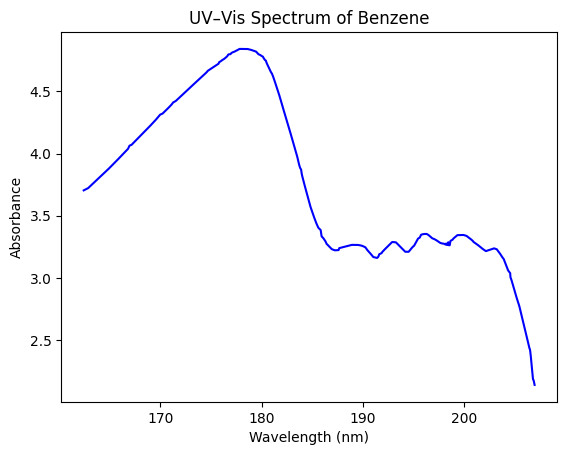

In [ ]:
wavelength_data = df["wavelength_nm"]
absorbance_data = df["absorbance"]
plt.plot(wavelength_data, absorbance_data, c='blue')
plt.xlabel("Wavelength (nm)") # adding label for x-axis
plt.ylabel("Absorbance") # adding label for x-axis
plt.title("UV–Vis Spectrum of Benzene") # adding plot title
# plt.show()

#### Extract peak value and indicate it on the plot

The peak wavelength tells you the wavelength of electronic transitions.
The peak width and area tells you the band broadening and the total absorption intensity.

In [ ]:
absorbance_max = df.loc[df["absorbance"].idxmax(), "absorbance"]
lambda_max = df.loc[df["absorbance"].idxmax(), "wavelength_nm"]
print("Peak absorbance:", absorbance_max)
print("Peak wavelength: ", lambda_max)
# The wavelength indicates pi-pi* excitation

Peak absorbance: 4.840938
Peak wavelength:  177.8264


Text(0.5, 1.0, 'UV–Vis Spectrum of Benzene')

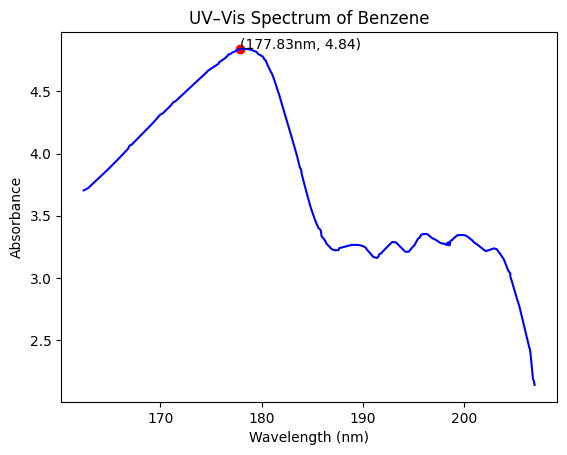

In [ ]:
plt.plot(wavelength_data, absorbance_data, c='blue')
plt.scatter(lambda_max, absorbance_max, c='red')
plt.xlabel("Wavelength (nm)")
plt.ylabel("Absorbance")
plt.text(lambda_max, absorbance_max, f"({lambda_max:.2f}nm, {absorbance_max:.2f})")
plt.title("UV–Vis Spectrum of Benzene")
# plt.show()

#### Let's look at the next excitation

peaks: 
 61     177.8264
132    188.9211
153    192.9069
177    196.3056
199    199.9460
Name: wavelength_nm, dtype: float64


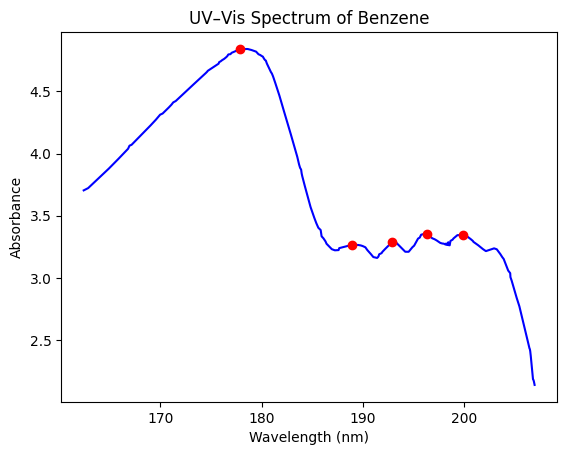

In [ ]:
from scipy.signal import find_peaks # scipy signals have functions to process signals
peaks, properties = find_peaks(absorbance_data, prominence=0.03)  # prominence measures how much a peak stands out from its surrounding baseline
plt.plot(wavelength_data, absorbance_data, c='blue')
plt.plot(wavelength_data[peaks], absorbance_data[peaks], "o", color='red', label="Peaks")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Absorbance")
plt.title("UV–Vis Spectrum of Benzene")
print("peaks: \n", wavelength_data[peaks])

# save the figure
plt.savefig("benzene_uvvis.png", dpi=400)
# for high resolution options, save as pdf or eps files, e.g.,
# plt.savefig("benzene_uvvis.pdf")


#### Your turn!
Pick another compound, analyze the spectrum, and decide on the electronic excitation type.

## Extra

The CSV file is not the original file I downloaded from NIST Chemistry WebBook. Now We will handle the original JCAMP-DX file.

Go to: https://webbook.nist.gov/chemistry/

Search a molecule based on its identifier (e.g. IUPAC, CAS numbers).

Get the UV--Vis spectrum data.

Handling JCAMP-DX file will need the `jcamp` package.

In [ ]:
!pip install jcamp

In [ ]:
import jcamp

### Some tricks to download a file without clicking:
Download link:

Right click the link -> Copy Link.

We will learn more from Website scraping (be careful!).

In [ ]:
# !mkdir -p uvvis_data
!wget -q "https://webbook.nist.gov/cgi/cbook.cgi?JCAMP=C71432&amp;Index=0&amp;Type=UVVis" -O uvvis_data/benzene_uvvis.jdx

In [ ]:
f = jcamp.jcamp_readfile("./uvvis_data/benzene_uvvis.jdx")

### Let's look at the schema of the data

In [ ]:
print(f.keys())

dict_keys(['title', 'jcamp-dx', 'data type', 'origin', 'owner', 'cas registry no', 'molform', 'mp', 'bp', 'source reference', '$nist squib', '$nist source', 'spectrometer/data system', 'xunits', 'yunits', 'xfactor', 'yfactor', 'firstx', 'lastx', 'firsty', 'maxx', 'minx', 'maxy', 'miny', 'npoints', '$ref author', '$ref title', '$ref journal', '$ref volume', '$ref page', '$ref date', 'xypoints', 'end', 'x', 'y', 'filename'])


In [ ]:
for key in f.keys():
  print(key, f[key])

title Benzene
jcamp-dx 4.24
data type UV/VIS SPECTRUM
origin INSTITUTE OF ENERGY PROBLEMS OF CHEMICAL PHYSICS, RAS
owner INEP CP RAS, NIST OSRD
Collection (C) 2007 copyright by the U.S. Secretary of Commerce
on behalf of the United States of America. All rights reserved.
cas registry no 71-43-2
molform C6H6
mp 5.5
bp 80.0
source reference RAS UV No. 118
$nist squib 1951ROM/VOD930-932
$nist source TSGMTE
spectrometer/data system n.i.g.
xunits Wavelength (nm)
yunits Logarithm epsilon
xfactor 1.0
yfactor 1.0
firstx 162.418
lastx 206.9805
firsty 3.70381
maxx 206.981
minx 162.418
maxy 4.84094
miny 2.13991
npoints 317
$ref author Romand, J.; Vodar, B.
$ref title Spectres d'absorption du benzene a l'etat vapeur et a l'etat condense dans l'ultraviolet lointain
$ref journal Compt. Rend.
$ref volume 233
$ref page 930-932
$ref date 1951
xypoints (XY..XY)
end 
x [162.418  162.5644 162.7108 162.8571 162.8571 163.3675 163.8777 164.388
 164.8982 164.8982 165.8329 166.3493 166.6163 166.8029 166.8029 1

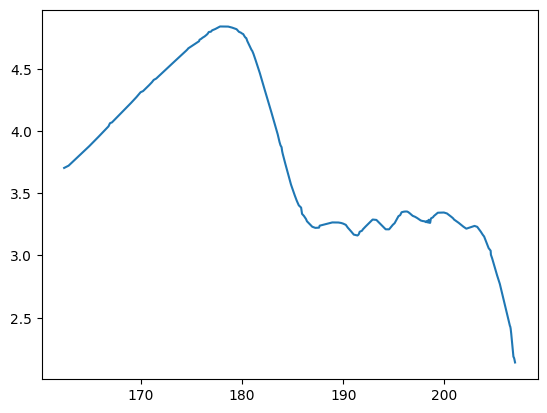

In [ ]:
plt.plot(f['x'], f['y'])